# Multi Model Comparisson
In this notebook, we will train three different models to observe the differences between them. For this purpose, we will use $10^6$ points instead of $10^8$.

In [1]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from collections import defaultdict
import numpy as np
import pandas as pd
import tensorflow as tf
import random
from tensorflow import keras
from tensorflow.keras.callbacks import ModelCheckpoint
from matplotlib import pyplot as plt
from utils.functions import (
    pid_to_latex,
    plot_pdf_comparison_multi,
    plot_pdf_valence_multi,
)
from models.layers import InputScaling, Preprocessing
from models.architecture import Model1, Model2, Model3, Model4, Model5, Model6

from IPython.display import display

tf.keras.backend.clear_session()

## Load the data ##

In [2]:
data_path = "data/"

try:
    x_q2_inputs = np.load(os.path.join(data_path, "x_q2_inputs_training.npy"))
    val_pdf = np.load(os.path.join(data_path, "pdf_targets_training.npy"))
    pids = np.load(os.path.join(data_path, "pids_info_training.npy"))
    print("Data successfully loaded. Data of NNPDF40_nnlo_as_01180 set is being used.")
    print(f"Inputs Format (X): {x_q2_inputs.shape}  -> [points, (x, Q2)]")
    print(f"Targets Format (y): {val_pdf.shape} -> [values, flavors]")
    print(f"PIDs included: {pids}")
except FileNotFoundError:
    print(
        "Error: Data files not found. Please ensure the .npy files are in the 'data/' directory."
    )
    exit(1)

input_xgrid = x_q2_inputs[:, 0]
input_q2grid = x_q2_inputs[:, 1]

pid_cols = {pid: i for i, pid in enumerate(pids)}
output_basis = [
    -4,
    -3,
    -2,
    -1,
    21,
    1,
    2,
    3,
    4,
]
noutput = len(output_basis)  # Number of flavors (columns in val_pdf)

output_data = np.zeros((len(val_pdf), noutput))
print(f"Number of samples: {len(val_pdf)}, Number of flavors: {noutput}")

pdf_grid = defaultdict(list)

for j, pid in enumerate(output_basis):
    col_idx = pid_cols[pid]
    output_data[:, j] = val_pdf[:, col_idx]

output_data = np.array(output_data)

# Normalize each column by its maximum value
max_vals = np.max(output_data, axis=0)
output_data_norm = output_data / max_vals

Data successfully loaded. Data of NNPDF40_nnlo_as_01180 set is being used.
Inputs Format (X): (1000000, 2)  -> [points, (x, Q2)]
Targets Format (y): (1000000, 11) -> [values, flavors]
PIDs included: [21  1  2  3  4  5 -1 -2 -3 -4 -5]
Number of samples: 1000000, Number of flavors: 9


# Training the models
To properly understand the differences between models, we need to keep in mind that TensorFlow can start each model training from a different point. To ensure they all start with the same seed, we implement the following function.

In [3]:
def reset_seeds(seed=42):
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    print(f"Seeds reset to {seed} and session cleared.")


results_path = "outputs/multimodel"

if not os.path.exists(results_path):
    os.makedirs(results_path)

The first model corresponds to the same model used in obj_1.ipynb.

In [4]:
reset_seeds(42)
model1 = Model1(input_shape=(2,), noutput=noutput)
model1.compile(optimizer=keras.optimizers.Nadam(learning_rate=0.0005), loss="mse")

chekpoint_callback1 = ModelCheckpoint(
    filepath=f"{results_path}/model1.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1,
)

history1 = model1.fit(
    x_q2_inputs,
    output_data_norm,
    epochs=1000,
    batch_size=1048,
    validation_split=0.3,
    callbacks=[chekpoint_callback1],
)

model1 = tf.keras.models.load_model(
    f"{results_path}/model1.keras",
    custom_objects={"InputScaling": InputScaling, "Preprocessing": Preprocessing},
)
predictions_norm1 = model1.predict(x_q2_inputs)
predictions1 = predictions_norm1 * max_vals
model1.summary()

np.savez(os.path.join(results_path, "model1.npz"), predictions=predictions1)

print("Results saved correctly.")

Seeds reset to 42 and session cleared.
Epoch 1/1000
656/668 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0094
Epoch 1: val_loss improved from None to 0.01089, saving model to outputs/multimodel/model1.keras

Epoch 1: finished saving model to outputs/multimodel/model1.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0024 - val_loss: 0.0109
Epoch 2/1000
661/668 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6827e-04
Epoch 2: val_loss improved from 0.01089 to 0.00850, saving model to outputs/multimodel/model1.keras

Epoch 2: finished saving model to outputs/multimodel/model1.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.4273e-04 - val_loss: 0.0085
Epoch 3/1000
660/668 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7874e-04
Epoch 3: val_loss improved from 0.00850 to 0.00757, saving model to outputs/multimodel/model1.keras

Epoch 3: finished saving model to outputs/multimodel/model1.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.7551e-04 - val_loss: 0.0076
Epoch 4/1000
66

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_scaling       │ (None, 3)         │          0 │ input_layer[0][0] │
│ (InputScaling)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        256 │ input_scaling[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 9)         │        585 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocessing       │ (None, 9)         │          9 │ input_layer[0][0] │
│ (Preprocessing)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 9)         │          0 │ dense_3[0][0],    │
│                     │                   │            │ preprocessing[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,513 (107.48 KB)

 Trainable params: 9,170 (35.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,343 (71.66 KB)

Results saved correctly.


The next model is the same as the previous one but trains twice as many times.

In [5]:
reset_seeds(42)
model2 = Model1(input_shape=(2,), noutput=noutput)
model2.compile(optimizer=keras.optimizers.Nadam(learning_rate=0.0005), loss="mse")

chekpoint_callback2 = ModelCheckpoint(
    filepath=f"{results_path}/model2.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1,
)

history2 = model2.fit(
    x_q2_inputs,
    output_data_norm,
    epochs=2000,
    batch_size=1048,
    validation_split=0.3,
    callbacks=[chekpoint_callback2],
)

model2 = tf.keras.models.load_model(
    f"{results_path}/model2.keras",
    custom_objects={"InputScaling": InputScaling, "Preprocessing": Preprocessing},
)
predictions_norm2 = model2.predict(x_q2_inputs)
predictions2 = predictions_norm2 * max_vals
model2.summary()

# Saving the data
np.savez(os.path.join(results_path, "model2.npz"), predictions=predictions2)

Seeds reset to 42 and session cleared.
Epoch 1/2000
651/668 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0095
Epoch 1: val_loss improved from None to 0.01089, saving model to outputs/multimodel/model2.keras

Epoch 1: finished saving model to outputs/multimodel/model2.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0024 - val_loss: 0.0109
Epoch 2/2000
643/668 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6894e-04
Epoch 2: val_loss improved from 0.01089 to 0.00850, saving model to outputs/multimodel/model2.keras

Epoch 2: finished saving model to outputs/multimodel/model2.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 2.4273e-04 - val_loss: 0.0085
Epoch 3/2000
662/668 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.7873e-04
Epoch 3: val_loss improved from 0.00850 to 0.00757, saving model to outputs/multimodel/model2.keras

Epoch 3: finished saving model to outputs/multimodel/model2.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 1.7551e-04 - val_loss: 0.0076
Epoch 4/2000
66

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_scaling       │ (None, 3)         │          0 │ input_layer[0][0] │
│ (InputScaling)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        256 │ input_scaling[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 9)         │        585 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocessing       │ (None, 9)         │          9 │ input_layer[0][0] │
│ (Preprocessing)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 9)         │          0 │ dense_3[0][0],    │
│                     │                   │            │ preprocessing[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,513 (107.48 KB)

 Trainable params: 9,170 (35.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,343 (71.66 KB)

The third model has the same layers as the first but with a greater density of these layers, that is, it is wider.

In [6]:
reset_seeds(42)
model3 = Model2(input_shape=(2,), noutput=noutput)
model3.compile(optimizer=keras.optimizers.Nadam(learning_rate=0.0005), loss="mse")

chekpoint_callback3 = ModelCheckpoint(
    filepath=f"{results_path}/model3.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1,
)

history3 = model3.fit(
    x_q2_inputs,
    output_data_norm,
    epochs=1000,
    batch_size=1048,
    validation_split=0.3,
    callbacks=[chekpoint_callback3],
)

model3 = tf.keras.models.load_model(
    f"{results_path}/model3.keras",
    custom_objects={"InputScaling": InputScaling, "Preprocessing": Preprocessing},
)
predictions_norm3 = model3.predict(x_q2_inputs)
predictions3 = predictions_norm3 * max_vals
model3.summary()

# Saving the data
np.savez(os.path.join(results_path, "model3.npz"), predictions=predictions3)

Seeds reset to 42 and session cleared.
Epoch 1/1000
668/668 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0033
Epoch 1: val_loss improved from None to 0.00846, saving model to outputs/multimodel/model3.keras

Epoch 1: finished saving model to outputs/multimodel/model3.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0013 - val_loss: 0.0085
Epoch 2/1000
663/668 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.6480e-04
Epoch 2: val_loss improved from 0.00846 to 0.00727, saving model to outputs/multimodel/model3.keras

Epoch 2: finished saving model to outputs/multimodel/model3.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 4.9432e-04 - val_loss: 0.0073
Epoch 3/1000
658/668 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5484e-04
Epoch 3: val_loss improved from 0.00727 to 0.00689, saving model to outputs/multimodel/model3.keras

Epoch 3: finished saving model to outputs/multimodel/model3.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 3.3799e-04 - val_loss: 0.0069
Epoch 4/1000
65

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_scaling       │ (None, 3)         │          0 │ input_layer[0][0] │
│ (InputScaling)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │      1,024 │ input_scaling[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │     65,792 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │     65,792 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 9)         │      2,313 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocessing       │ (None, 9)         │          9 │ input_layer[0][0] │
│ (Preprocessing)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 9)         │          0 │ dense_3[0][0],    │
│                     │                   │            │ preprocessing[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 404,793 (1.54 MB)

 Trainable params: 134,930 (527.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 269,863 (1.03 MB)

The fourth model is the same as the first but with more layers, that is, it is deeper.

In [7]:
reset_seeds(42)
model4 = Model3(input_shape=(2,), noutput=noutput)
model4.compile(optimizer=keras.optimizers.Nadam(learning_rate=0.0005), loss="mse")

chekpoint_callback4 = ModelCheckpoint(
    filepath=f"{results_path}/model4.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1,
)

history4 = model4.fit(
    x_q2_inputs,
    output_data_norm,
    epochs=1000,
    batch_size=1048,
    validation_split=0.3,
    callbacks=[chekpoint_callback4],
)

model4 = tf.keras.models.load_model(
    f"{results_path}/model4.keras",
    custom_objects={"InputScaling": InputScaling, "Preprocessing": Preprocessing},
)
predictions_norm4 = model4.predict(x_q2_inputs)
predictions4 = predictions_norm4 * max_vals
model4.summary()

# Saving the data
np.savez(os.path.join(results_path, "model4.npz"), predictions=predictions4)


Seeds reset to 42 and session cleared.
Epoch 1/1000
652/668 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025
Epoch 1: val_loss improved from None to 0.00986, saving model to outputs/multimodel/model4.keras

Epoch 1: finished saving model to outputs/multimodel/model4.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 8.6248e-04 - val_loss: 0.0099
Epoch 2/1000
655/668 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.3492e-04
Epoch 2: val_loss improved from 0.00986 to 0.00644, saving model to outputs/multimodel/model4.keras

Epoch 2: finished saving model to outputs/multimodel/model4.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.0695e-04 - val_loss: 0.0064
Epoch 3/1000
664/668 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 5.9670e-05
Epoch 3: val_loss improved from 0.00644 to 0.00467, saving model to outputs/multimodel/model4.keras

Epoch 3: finished saving model to outputs/multimodel/model4.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 5.6236e-05 - val_loss: 0.0047
Epoch 4/100

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_scaling       │ (None, 3)         │          0 │ input_layer[0][0] │
│ (InputScaling)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        256 │ input_scaling[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │      4,160 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 64)        │      4,160 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 9)         │        585 │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocessing       │ (None, 9)         │          9 │ input_layer[0][0] │
│ (Preprocessing)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 9)         │          0 │ dense_6[0][0],    │
│                     │                   │            │ preprocessing[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 64,953 (253.73 KB)

 Trainable params: 21,650 (84.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 43,303 (169.16 KB)

The 5th Model has just one dense layer.

In [8]:
reset_seeds(42)
model5 = Model4(input_shape=(2,), noutput=noutput)
model5.compile(optimizer=keras.optimizers.Nadam(learning_rate=0.0005), loss="mse")

chekpoint_callback5 = ModelCheckpoint(
    filepath=f"{results_path}/model5.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1,
)

history5 = model5.fit(
    x_q2_inputs,
    output_data_norm,
    epochs=1000,
    batch_size=1048,
    validation_split=0.3,
    callbacks=[chekpoint_callback5],
)

model5 = tf.keras.models.load_model(
    f"{results_path}/model5.keras",
    custom_objects={"InputScaling": InputScaling, "Preprocessing": Preprocessing},
)
predictions_norm5 = model5.predict(x_q2_inputs)
predictions5 = predictions_norm5 * max_vals
model5.summary()

# Saving the data
np.savez(os.path.join(results_path, "model5.npz"), predictions=predictions5)

Seeds reset to 42 and session cleared.
Epoch 1/1000
639/668 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1214
Epoch 1: val_loss improved from None to 0.01888, saving model to outputs/multimodel/model5.keras

Epoch 1: finished saving model to outputs/multimodel/model5.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0336 - val_loss: 0.0189
Epoch 2/1000
638/668 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014
Epoch 2: val_loss improved from 0.01888 to 0.01575, saving model to outputs/multimodel/model5.keras

Epoch 2: finished saving model to outputs/multimodel/model5.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0012 - val_loss: 0.0158
Epoch 3/1000
648/668 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 8.0239e-04
Epoch 3: val_loss improved from 0.01575 to 0.01350, saving model to outputs/multimodel/model5.keras

Epoch 3: finished saving model to outputs/multimodel/model5.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 7.3104e-04 - val_loss: 0.0135
Epoch 4/1000
651/668 ━━

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_scaling       │ (None, 3)         │          0 │ input_layer[0][0] │
│ (InputScaling)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        256 │ input_scaling[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 9)         │        585 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocessing       │ (None, 9)         │          9 │ input_layer[0][0] │
│ (Preprocessing)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 9)         │          0 │ dense_1[0][0],    │
│                     │                   │            │ preprocessing[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,553 (9.98 KB)

 Trainable params: 850 (3.32 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,703 (6.66 KB)

The 6th Model is the same that the 1st one but with an activation "linear" instead of "tanh".

In [9]:
reset_seeds(42)
model6 = Model5(input_shape=(2,), noutput=noutput)
model6.compile(optimizer=keras.optimizers.Nadam(learning_rate=0.0005), loss="mse")

chekpoint_callback6 = ModelCheckpoint(
    filepath=f"{results_path}/model6.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1,
)

history6 = model6.fit(
    x_q2_inputs,
    output_data_norm,
    epochs=1000,
    batch_size=1048,
    validation_split=0.3,
    callbacks=[chekpoint_callback6],
)

model6 = tf.keras.models.load_model(
    f"{results_path}/model6.keras",
    custom_objects={"InputScaling": InputScaling, "Preprocessing": Preprocessing},
)
predictions_norm6 = model6.predict(x_q2_inputs)
predictions6 = predictions_norm6 * max_vals
model6.summary()

# Saving the data
np.savez(os.path.join(results_path, "model6.npz"), predictions=predictions6)

Seeds reset to 42 and session cleared.
Epoch 1/1000
655/668 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0749
Epoch 1: val_loss improved from None to 0.01306, saving model to outputs/multimodel/model6.keras

Epoch 1: finished saving model to outputs/multimodel/model6.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0148 - val_loss: 0.0131
Epoch 2/1000
667/668 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0017
Epoch 2: val_loss improved from 0.01306 to 0.01280, saving model to outputs/multimodel/model6.keras

Epoch 2: finished saving model to outputs/multimodel/model6.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0017 - val_loss: 0.0128
Epoch 3/1000
655/668 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018
Epoch 3: val_loss improved from 0.01280 to 0.01245, saving model to outputs/multimodel/model6.keras

Epoch 3: finished saving model to outputs/multimodel/model6.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0018 - val_loss: 0.0124
Epoch 4/1000
650/668 ━━━━━━━━━━

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_scaling       │ (None, 3)         │          0 │ input_layer[0][0] │
│ (InputScaling)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │        256 │ input_scaling[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      4,160 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 9)         │        585 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocessing       │ (None, 9)         │          9 │ input_layer[0][0] │
│ (Preprocessing)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 9)         │          0 │ dense_3[0][0],    │
│                     │                   │            │ preprocessing[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,513 (107.48 KB)

 Trainable params: 9,170 (35.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 18,343 (71.66 KB)

Finally the 7th Model it's a reproduction of the model used by NNPDF4.0.

In [10]:
reset_seeds(42)
model7 = Model6(input_shape=(2,), noutput=noutput)
model7.compile(optimizer=keras.optimizers.Nadam(learning_rate=0.0005), loss="mse")

chekpoint_callback7 = ModelCheckpoint(
    filepath=f"{results_path}/model7.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1,
)

history7 = model7.fit(
    x_q2_inputs,
    output_data_norm,
    epochs=1000,
    batch_size=1048,
    validation_split=0.3,
    callbacks=[chekpoint_callback7],
)

model7 = tf.keras.models.load_model(
    f"{results_path}/model7.keras",
    custom_objects={"InputScaling": InputScaling, "Preprocessing": Preprocessing},
)
predictions_norm7 = model7.predict(x_q2_inputs)
predictions7 = predictions_norm7 * max_vals
model7.summary()

# Saving the data
np.savez(os.path.join(results_path, "model7.npz"), predictions=predictions7)

Seeds reset to 42 and session cleared.
Epoch 1/1000
636/668 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0379
Epoch 1: val_loss improved from None to 0.02155, saving model to outputs/multimodel/model7.keras

Epoch 1: finished saving model to outputs/multimodel/model7.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.0118 - val_loss: 0.0215
Epoch 2/1000
646/668 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0015
Epoch 2: val_loss improved from 0.02155 to 0.01452, saving model to outputs/multimodel/model7.keras

Epoch 2: finished saving model to outputs/multimodel/model7.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0013 - val_loss: 0.0145
Epoch 3/1000
665/668 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.8497e-04
Epoch 3: val_loss improved from 0.01452 to 0.01111, saving model to outputs/multimodel/model7.keras

Epoch 3: finished saving model to outputs/multimodel/model7.keras
668/668 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.9066e-04 - val_loss: 0.0111
Epoch 4/1000
639/668 ━━

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_scaling       │ (None, 3)         │          0 │ input_layer[0][0] │
│ (InputScaling)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 25)        │        100 │ input_scaling[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20)        │        520 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 8)         │        168 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 9)         │         81 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ preprocessing       │ (None, 9)         │          9 │ input_layer[0][0] │
│ (Preprocessing)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 9)         │          0 │ dense_3[0][0],    │
│                     │                   │            │ preprocessing[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,637 (10.30 KB)

 Trainable params: 878 (3.43 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,759 (6.88 KB)

Finally, we store all the predictions together for later discussion.

In [11]:
models = {
    "Model 1 (Base)": predictions1,
    "Model 2 (Epochs)": predictions2,
    "Model 3 (Wider)": predictions3,
    "Model 4 (Deeper)": predictions4,
    "Model 5 (One Dense)": predictions5,
    "Model 6 (Linear)": predictions6,
    "Model 7 (NNPDF)": predictions7,
}

# Results
First, we will see how our models approximate each flavor.

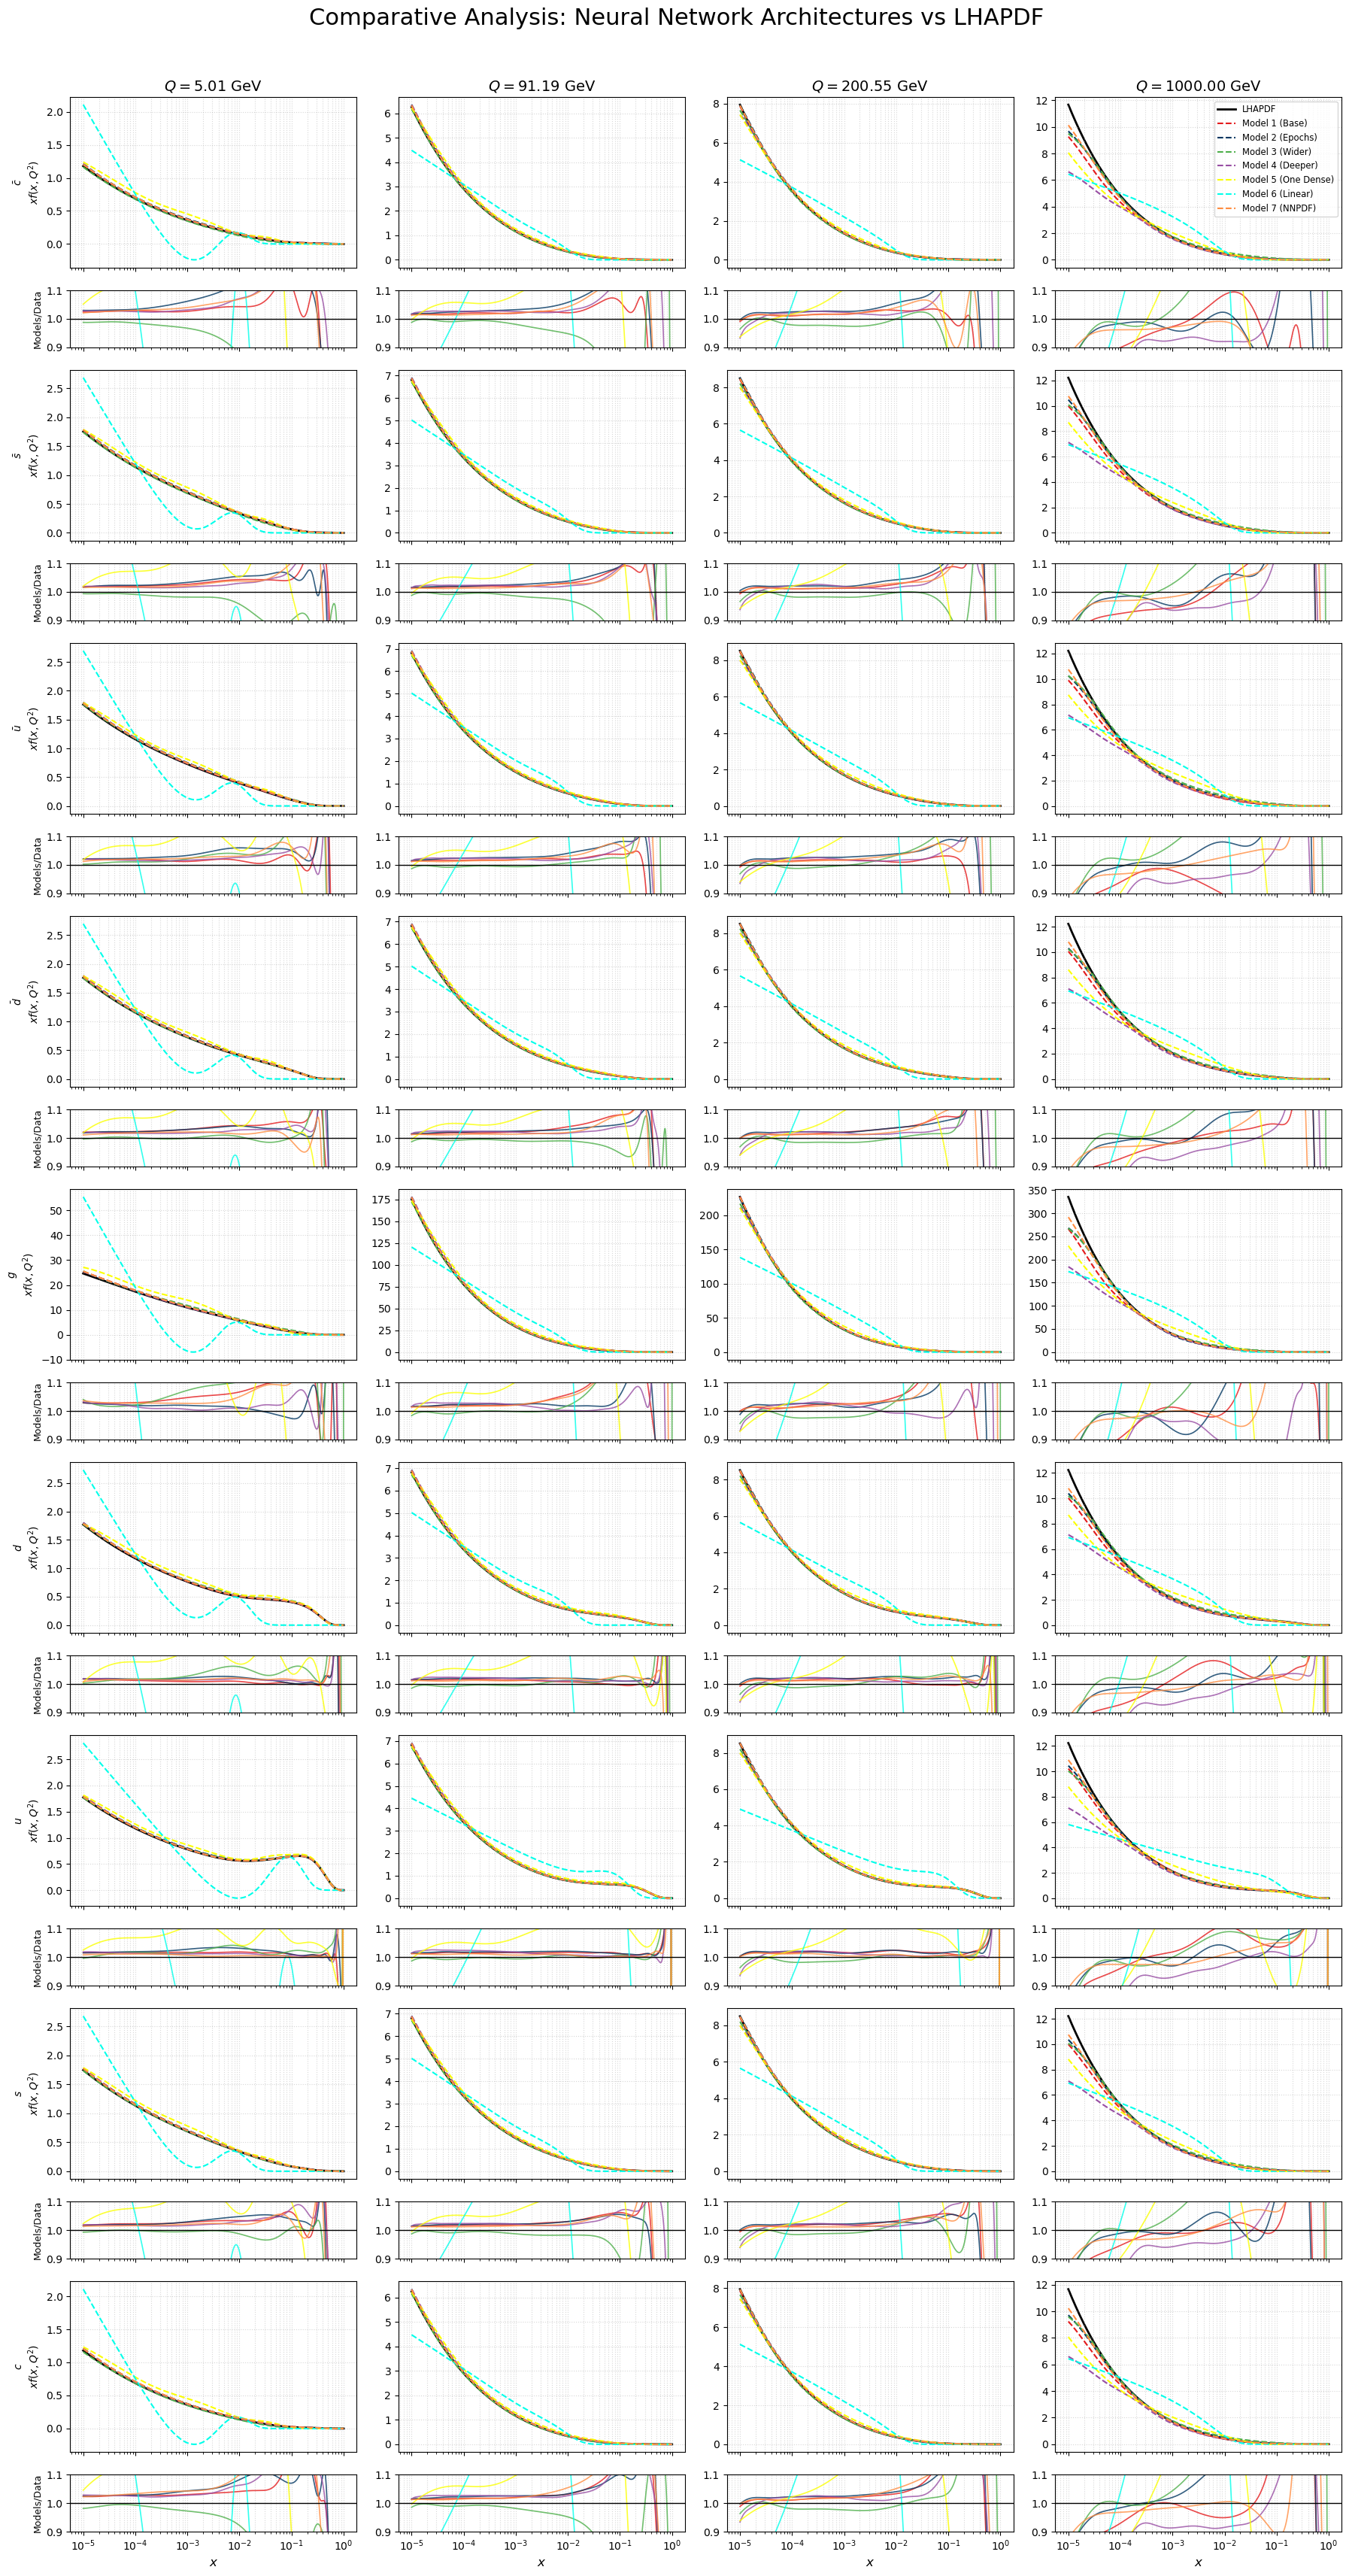

In [12]:
q_values = [5, 91, 200, 1000]
names = [pid_to_latex(p) for p in output_basis]
results_folder = "results/multi model"

plot_pdf_comparison_multi(
    input_xgrid,
    input_q2grid,
    output_data,
    models,
    output_basis,
    output_basis,
    names,
    q_values,
)

plt.show()

Next, we will see a more practical representation showing the q valences and the sea of ​​quarks.

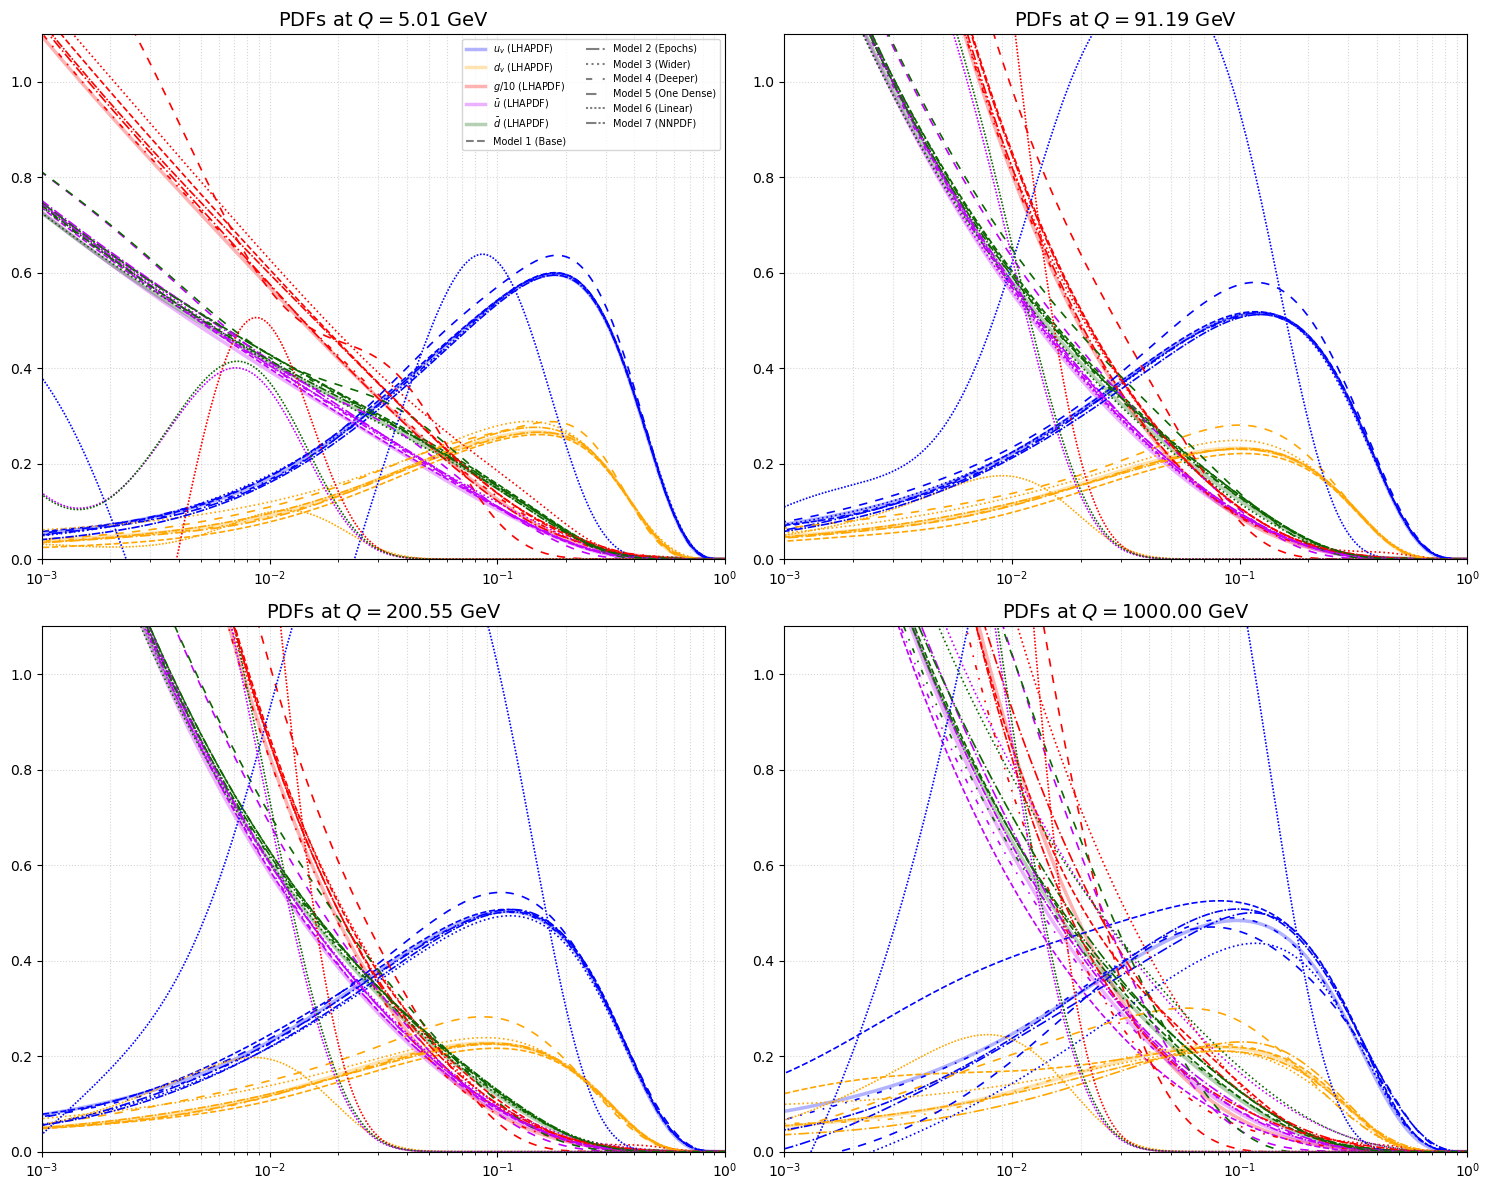

In [13]:
plot_pdf_valence_multi(input_xgrid, input_q2grid, output_data, models, q_values)
plt.show()

Finally, we will see how the summation rules are met and which model best approximates the theoretical values.

In [16]:
# Next, we will verify if our NNs have been able to learn certain physical constraints on their own.
# 1. Input Configuration
target_q = 91
target_q2 = target_q**2

# Index mapping for flavors and anti-flavors
idx = {
    "u": 6,
    "u_bar": 2,
    "d": 5,
    "d_bar": 3,
    "s": 7,
    "s_bar": 1,
    "c": 8,
    "c_bar": 0,
    "g": 4,
}

# 2. Robust Q2 Scale Selection
available_q2 = np.unique(input_q2grid)
closest_q2 = available_q2[np.abs(available_q2 - target_q2).argmin()]
mask = input_q2grid.flatten() == closest_q2

# 3. Data Extraction and Sorting by x
x_vals = input_xgrid.flatten()[mask]
sort_indices = np.argsort(x_vals)
x_f = x_vals[sort_indices]
y_true_f = output_data[mask][sort_indices]

dict_predictions = {}

for model_name, preds in models.items():
    dict_predictions[model_name] = preds[mask][sort_indices]


def generate_multi_model_physics_report(
    x, y_true, dict_predictions, f_map, q2_value, export_path=None
):
    """
    Calculates sum rules and fidelity (MSE) for multiple models
    and generates a comparative table.
    """
    if len(x) == 0:
        print(f"Error: No data available for Q2 = {q2_value}.")
        return None

    safe_x = np.where(x == 0, 1e-10, x)

    # 1. --- REFERENCE CALCULATIONS (LHAPDF / Ground Truth) ---
    mom_t = np.trapz(np.sum([y_true[:, i] for i in f_map.values()], axis=0), x)

    def get_val_true(flavor):
        return np.trapz(
            (y_true[:, f_map[flavor]] - y_true[:, f_map[f"{flavor}_bar"]]) / safe_x, x
        )

    # 2. --- TABLE DATA STRUCTURE ---
    report_data = [
        {"Sum Rule": "Total Momentum", "Target": 1.0, "LHAPDF": mom_t},
        {"Sum Rule": "u Valence", "Target": 2.0, "LHAPDF": get_val_true("u")},
        {"Sum Rule": "d Valence", "Target": 1.0, "LHAPDF": get_val_true("d")},
        {"Sum Rule": "s Valence", "Target": 0.0, "LHAPDF": get_val_true("s")},
        {"Sum Rule": "c Valence", "Target": 0.0, "LHAPDF": get_val_true("c")},
        {"Sum Rule": "Fidelity (MSE)", "Target": "---", "LHAPDF": "---"},
    ]

    # 3. --- PER-MODEL CALCULATIONS ---
    for m_name, y_pred in dict_predictions.items():
        # Physical sum rules
        mom_p = np.trapz(np.sum([y_pred[:, i] for i in f_map.values()], axis=0), x)

        def get_val_pred(flavor):
            return np.trapz(
                (y_pred[:, f_map[flavor]] - y_pred[:, f_map[f"{flavor}_bar"]]) / safe_x,
                x,
            )

        # Fidelity metric: Mean Squared Error
        mse_p = np.mean((y_pred - y_true) ** 2)

        # Map results
        report_data[0][m_name] = mom_p
        report_data[1][m_name] = get_val_pred("u")
        report_data[2][m_name] = get_val_pred("d")
        report_data[3][m_name] = get_val_pred("s")
        report_data[4][m_name] = get_val_pred("c")
        report_data[5][m_name] = mse_p

    df = pd.DataFrame(report_data)

    # 4. --- LATEX EXPORT ---
    if export_path and export_path.endswith(".tex"):
        df.to_latex(
            export_path,
            index=False,
            float_format=lambda x: f"{x:.4f}",  # Using scientific notation for MSE
            caption=f"Comparison of Physical Sum Rules and Fidelity at $Q={np.sqrt(q2_value):.2f}$ GeV",
            label="tab:sum_rules_multi_model",
            escape=False,
        )

    return df.style.format(precision=4)


# 5. Execution and Display

output_tex_path = os.path.join(results_path, "momentum_rules.tex")

report_df = generate_multi_model_physics_report(
    x_f, y_true_f, dict_predictions, idx, closest_q2, export_path=output_tex_path
)

# Table Styling
display(report_df)


/tmp/ipykernel_22299/655290586.py:93: FutureWarning: In future versions `DataFrame.to_latex` is expected to utilise the base implementation of `Styler.to_latex` for formatting and rendering. The arguments signature may therefore change. It is recommended instead to use `DataFrame.style.to_latex` which also contains additional functionality.
  df.to_latex(


,Sum Rule,Target,LHAPDF,Model 1 (Base),Model 2 (Epochs),Model 3 (Wider),Model 4 (Deeper),Model 5 (One Dense),Model 6 (Linear),Model 7 (NNPDF)
0,Total Momentum,1.0000,0.9734,1.0346,1.0040,1.0473,0.9911,1.0684,0.6444,1.0414
1,u Valence,2.0000,1.9639,1.9448,1.8719,1.9623,1.9484,2.1285,2.4927,1.8639
2,d Valence,1.0000,0.9652,0.8739,0.9461,1.0394,0.9553,1.1828,0.4584,0.9558
3,s Valence,0.0000,0.0198,0.0133,-0.0037,0.0559,0.0214,0.0240,-0.0125,0.0088
4,c Valence,0.0000,-0.0006,-0.0041,-0.0601,0.0008,0.0018,0.1141,0.0016,0.0123
5,Fidelity (MSE),---,---,0.0857,0.1025,0.0157,0.1874,0.6770,14.8002,0.0603


# Conlusions

As we can see in the table, the model that best approximates the expected LHAPDF results is the one with the lowest MSE value. Therefore, model 2 is the best approximation.

It is also worth noting the significant difference between models 3 and 4, making it quite clear that for our purpose, a wide model is better than a deep one.